# Theoretical relation analysis
The theoretical relation between water and sediment discharges is:
$ y [t/h]= 0,0093 x^2 + 4,2903 x - 202,1$

x in $m^3/s$
following a Jaggi relation.

In [132]:
#  imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [133]:
# import datasets

multi_scan=pd.read_csv("Multi_flood_final.dat", sep='\t', header=1, 
                       usecols=[0,1,9,16])
multi_scan.columns=['Time[s]', 'Q [m3/s]', 'Qsed_out_tot[m3/s]','Qsed_in_tot[m3/s]']
multi_scan['Qsed_out_tot[m3/s]']=abs(multi_scan['Qsed_out_tot[m3/s]']) # make sure sediment discharge is positive
multi_scan['Qsed_in_tot[m3/s]']=abs(multi_scan['Qsed_in_tot[m3/s]'])
print(multi_scan.head())

single_scan=pd.read_csv(r"Single_flood_1.dat", sep='\t', header=1,
                        usecols=[0,1,4,6])
single_scan.columns=['Time[s]', 'Q [m3/s]', 'Qsed_out[m3/s]','Qsed_in tot [m3/s]']

single_scan['Qsed_out[m3/s]']=single_scan['Qsed_out[m3/s]'].clip(0) # make sure sediment discharge is positive
single_scan['Qsed_in tot [m3/s]']=single_scan['Qsed_in tot [m3/s]'].clip(0) # make sure sediment discharge is positive
# Theoretical
# relation

def jaggi_relation(x):
    return 0.0093*x**2 + 4.2903*x - 202.1
# x in m3/s
# y in t/h

rho_sediment=2650 #kg/m3

def sediment_discharge(Q_sed):
    """Convert sediment discharge from t/h to m3/s"""
    Q_sed_m3s = Q_sed / rho_sediment *1000/ 3600
    return Q_sed_m3s



   Time[s]  Q [m3/s]  Qsed_out_tot[m3/s]  Qsed_in_tot[m3/s]
0   1000.0  7.259774                 0.0                0.0
1   2000.0  7.013074                 0.0                0.0
2   3000.0  6.882195                 0.0                0.0
3   4000.0  6.756698                 0.0                0.0
4   5000.0  6.637665                 0.0                0.0


In [134]:
# theoretical sediment discharge from scan period discharge
multi_scan['Q_sed_theoretical_tph'] = jaggi_relation(multi_scan['Q [m3/s]'])
multi_scan['Q_sed_theoretical_m3s'] = sediment_discharge(multi_scan['Q_sed_theoretical_tph']).clip(lower=0) # clip negative values to 0
print(multi_scan.head())


   Time[s]  Q [m3/s]  Qsed_out_tot[m3/s]  Qsed_in_tot[m3/s]  \
0   1000.0  7.259774                 0.0                0.0   
1   2000.0  7.013074                 0.0                0.0   
2   3000.0  6.882195                 0.0                0.0   
3   4000.0  6.756698                 0.0                0.0   
4   5000.0  6.637665                 0.0                0.0   

   Q_sed_theoretical_tph  Q_sed_theoretical_m3s  
0            -170.463240                    0.0  
1            -171.554405                    0.0  
2            -172.132829                    0.0  
3            -172.687166                    0.0  
4            -173.212680                    0.0  


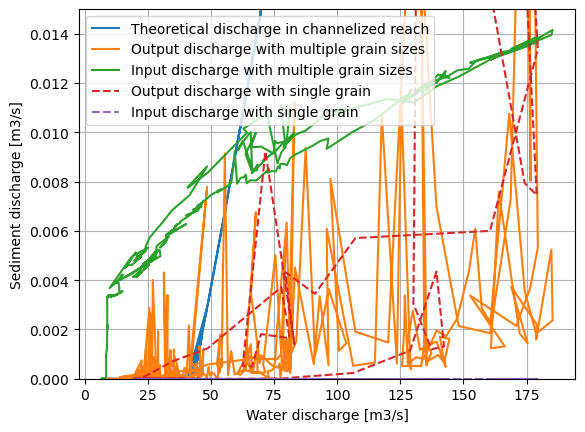

In [135]:
# plot sed discharges
plt.grid()
plt.plot(multi_scan['Q [m3/s]'],multi_scan['Q_sed_theoretical_m3s'], label='Theoretical discharge in channelized reach')
plt.plot(multi_scan['Q [m3/s]'],multi_scan['Qsed_out_tot[m3/s]'], label='Output discharge with multiple grain sizes')
plt.plot(multi_scan['Q [m3/s]'],multi_scan['Qsed_in_tot[m3/s]'], label='Input discharge with multiple grain sizes')
plt.plot(single_scan['Q [m3/s]'], single_scan['Qsed_out[m3/s]'],'--', label='Output discharge with single grain')
plt.plot(single_scan['Q [m3/s]'], single_scan['Qsed_in tot [m3/s]'],'--', label='Input discharge with single grain')



plt.xlabel('Water discharge [m3/s]')
plt.ylabel('Sediment discharge [m3/s]')
plt.ylim(0,0.015)
plt.legend()

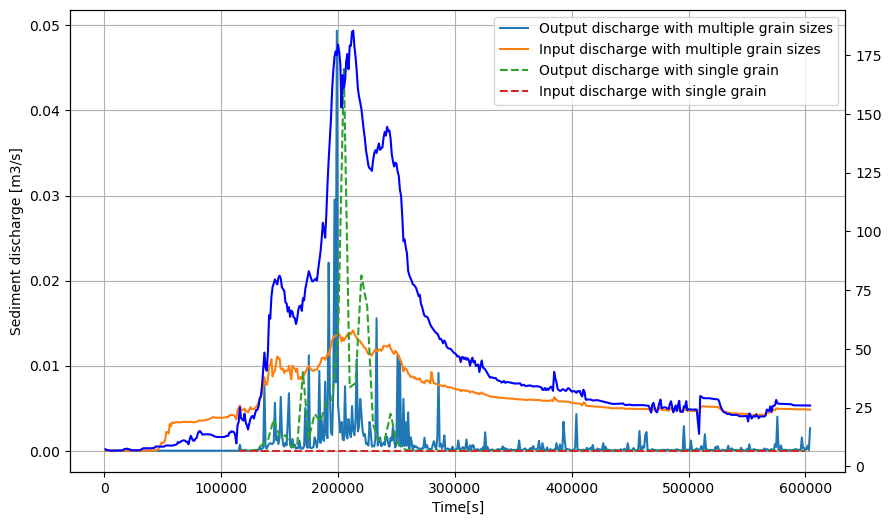

In [136]:
#plot timeseries of bedload
fig,ax=plt.subplots(figsize=(10,6))
ax.grid()
#ax.plot(multi_scan['Time[s]'],multi_scan['Q_sed_theoretical_m3s'], label='Theoretical discharge in channelized reach')
ax.plot(multi_scan['Time[s]'],multi_scan['Qsed_out_tot[m3/s]'], label='Output discharge with multiple grain sizes')
ax.plot(multi_scan['Time[s]'],multi_scan['Qsed_in_tot[m3/s]'], label='Input discharge with multiple grain sizes')
ax.plot(single_scan['Time[s]'], single_scan['Qsed_out[m3/s]'],'--', label='Output discharge with single grain')
ax.plot(single_scan['Time[s]'], single_scan['Qsed_in tot [m3/s]'],'--', label='Input discharge with single grain')


ax2=ax.twinx()
ax2.plot(multi_scan['Time[s]'], multi_scan['Q [m3/s]'], color='blue', label='Input water discharge')
ax.set_xlabel('Time[s]')
ax.set_ylabel('Sediment discharge [m3/s]')

ax.legend()

C:\Users\marga\AppData\Local\Temp\ipykernel_4132\22945864.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


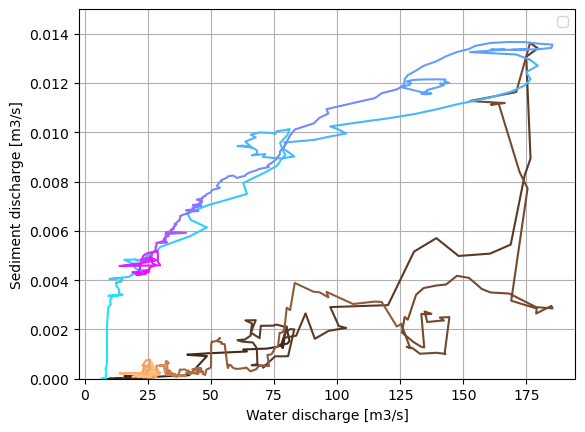

In [137]:
# smoothed discharges

multi_scan['Qsed_out_tot[m3/s]_smooth'] = multi_scan['Qsed_out_tot[m3/s]'].rolling(window=10).mean()
multi_scan['Qsed_in_tot[m3/s]_smooth'] = multi_scan['Qsed_in_tot[m3/s]'].rolling(window=10).mean()
single_scan['Qsed_out[m3/s]_smooth'] = single_scan['Qsed_out[m3/s]'].rolling(window=10).mean()
single_scan['Qsed_in tot [m3/s]_smooth'] = single_scan['Qsed_in tot [m3/s]'].rolling(window=10).mean()
plt.figure()
plt.grid()



def plot_colored(x, y, c, cmap=plt.cm.jet, steps=50):
    c = np.asarray(c)
    c -= c.min()
    c = c/c.max()
    it=0
    while it<c.size-steps:
        x_segm = x[it:it+steps+1]
        y_segm = y[it:it+steps+1]
        c_segm = cmap( c[it+steps//2] )
        plt.plot(x_segm, y_segm, c=c_segm)
        it += steps
plot_colored(x=multi_scan['Q [m3/s]'], y=multi_scan['Qsed_out_tot[m3/s]_smooth'],c=multi_scan['Time[s]'], cmap=plt.cm.copper)
plot_colored(x=multi_scan['Q [m3/s]'], y=multi_scan['Qsed_in_tot[m3/s]_smooth'],c=multi_scan['Time[s]'], cmap=plt.cm.cool)


plt.xlabel('Water discharge [m3/s]')
plt.ylabel('Sediment discharge [m3/s]')
plt.ylim(0,0.015)
plt.legend()
         

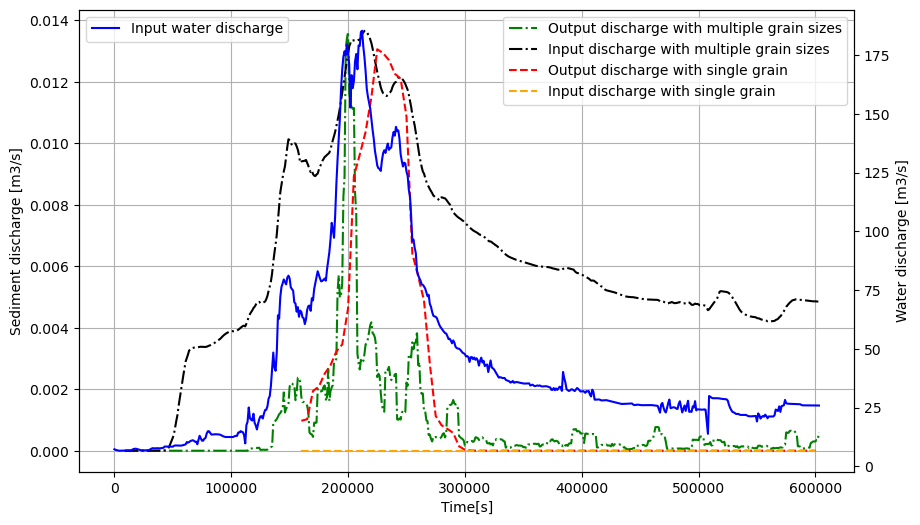

In [138]:
#plot timeseries of bedload
fig,ax=plt.subplots(figsize=(10,6))
ax.grid()
#ax.plot(multi_scan['Time[s]'],multi_scan['Q_sed_theoretical_m3s'], label='Theoretical discharge in channelized reach')
ax.plot(multi_scan['Time[s]'],multi_scan['Qsed_out_tot[m3/s]_smooth'],'-.', color='green', label='Output discharge with multiple grain sizes')
ax.plot(multi_scan['Time[s]'],multi_scan['Qsed_in_tot[m3/s]_smooth'], '-.',color='black',label='Input discharge with multiple grain sizes')
ax.plot(single_scan['Time[s]'], single_scan['Qsed_out[m3/s]_smooth'],'--', color='red', label='Output discharge with single grain')
ax.plot(single_scan['Time[s]'], single_scan['Qsed_in tot [m3/s]_smooth'],'--', color='orange',label='Input discharge with single grain')

ax.set_ylabel('Sediment discharge [m3/s]')
ax.set_xlabel('Time[s]')
ax.legend()

#secondary axis
ax2=ax.twinx()
ax2.plot(multi_scan['Time[s]'], multi_scan['Q [m3/s]'], color='blue', label='Input water discharge')
ax2.set_ylabel('Water discharge [m3/s]')
ax2.legend(loc='upper left')

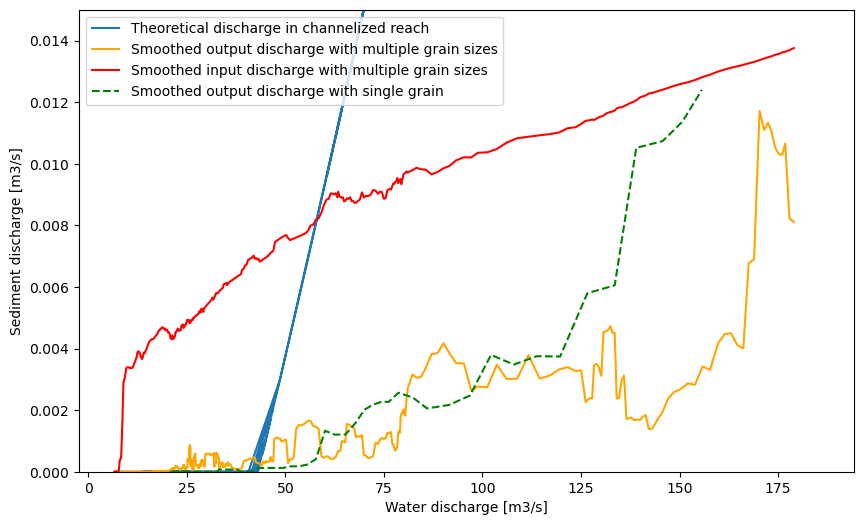

In [160]:
# Smoothed discharge curves
# First, sort on Q [m3/s]
fig,ax=plt.subplots(figsize=(10,6))
multi_scan_smooth=multi_scan.sort_values(by='Q [m3/s]')
multi_scan_smooth = multi_scan_smooth.rolling(window=10).mean()
plt.plot(multi_scan['Q [m3/s]'],multi_scan['Q_sed_theoretical_m3s'], label='Theoretical discharge in channelized reach')
plt.plot(multi_scan_smooth['Q [m3/s]'],multi_scan_smooth['Qsed_out_tot[m3/s]'], label='Smoothed output discharge with multiple grain sizes', color='orange')
plt.plot(multi_scan_smooth['Q [m3/s]'],multi_scan_smooth['Qsed_in_tot[m3/s]'], label='Smoothed input discharge with multiple grain sizes', color='red')
#Same for single scan
single_scan_smooth=single_scan.sort_values(by='Q [m3/s]')
single_scan_smooth = single_scan_smooth.rolling(window=10).mean()
plt.plot(single_scan_smooth['Q [m3/s]'], single_scan_smooth['Qsed_out[m3/s]'], '--',label='Smoothed output discharge with single grain', color='green')
#plt.plot(single_scan_smooth['Q [m3/s]'], single_scan_smooth['Qsed_in tot [m3/s]'], '--',label='Smoothed input discharge with single grain', color='purple')


plt.xlabel('Water discharge [m3/s]')
plt.ylabel('Sediment discharge [m3/s]')
plt.ylim(0,0.015)
plt.legend(loc="upper left")

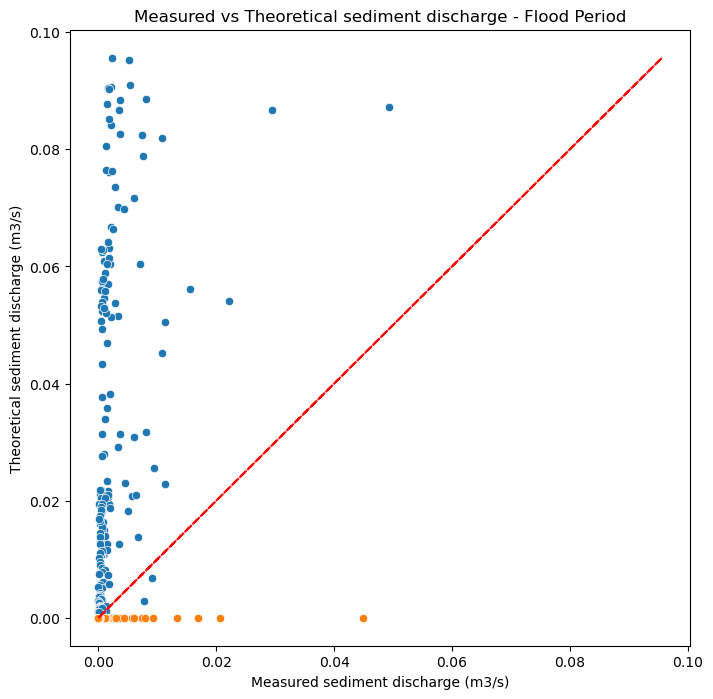

In [140]:
# QQ plots

ax, fig = plt.subplots(figsize=(8,8))
sns.scatterplot(data=multi_scan, x='Qsed_out_tot[m3/s]', y='Q_sed_theoretical_m3s')
sns.scatterplot( x=single_scan['Qsed_out[m3/s]'], y=multi_scan['Q_sed_theoretical_m3s'])

plt.plot(multi_scan['Q_sed_theoretical_m3s'],multi_scan['Q_sed_theoretical_m3s'], color='red', linestyle='--')
plt.xlabel('Measured sediment discharge (m3/s)')
plt.ylabel('Theoretical sediment discharge (m3/s)')
plt.title('Measured vs Theoretical sediment discharge - Flood Period')
plt.show()


In [155]:
# total sediment volume during multi scan periods
print( multi_scan['Qsed_out_tot[m3/s]'])
total_sediment_volume_m3 = (multi_scan['Qsed_out_tot[m3/s]']*1000).sum()
print(f'Total sediment volume during study period: {total_sediment_volume_m3:.2f} m3')

theoretical_total_sediment_volume_m3 = (multi_scan['Q_sed_theoretical_m3s']*1000).sum()
print(f'Theoretical total sediment volume during study period: {theoretical_total_sediment_volume_m3:.2f} m3')

total_sediment_addition_m3= (multi_scan['Qsed_in_tot[m3/s]']*1000).sum()-total_sediment_volume_m3
print(f'Total sediment volume during study period staying in the widening: {total_sediment_addition_m3:.2f} m3')

0      0.000000
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
599    0.000112
600    0.000174
601    0.000619
602    0.000073
603    0.002646
Name: Qsed_out_tot[m3/s], Length: 604, dtype: float64
Total sediment volume during study period: 505.04 m3
Theoretical total sediment volume during study period: 5884.13 m3
Total sediment volume during study period staying in the widening: 3141.86 m3


## Sediment sizes analysis
Using flood event of 2000


In [142]:

#initial sediment distribution

Sizes_classes_mm = [7, 20, 33, 46, 59] # in mm
sediment_init_percentage= [36.4, 20.6, 11.8, 16.0, 15.2] # in %

# import matrix of sediment percentages for 5 classes for each timestep
X_out=pd.read_csv("Multi_flood_final.dat", sep='\t', header=0, usecols=[10,11,12,13,14])
X_out


,bnd_outflow[Qsed d=7 mm [m3/s]],bnd_outflow[Qsed d=20 mm [m3/s]],bnd_outflow[Qsed d=33 mm [m3/s]],bnd_outflow[Qsed d=46 mm [m3/s]],bnd_outflow[Qsed d=59 mm [m3/s]]
0,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
2,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
3,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
4,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...
600,0.000095,0.000016,1.027025e-06,8.542848e-08,6.030601e-10
601,0.000147,0.000025,1.623556e-06,7.213252e-08,5.916155e-10
602,0.000514,0.000096,7.687100e-06,1.410349e-06,6.171040e-09
603,0.000063,0.000010,4.694065e-07,2.089325e-08,1.219138e-10


In [143]:
# average sediment percentage over the flood event
average_sediment_percentage = X_out.sum(axis=0) /X_out.sum(axis=0).sum()*100
average_sediment_percentage

bnd_outflow[Qsed d=7 mm [m3/s]]      62.620032
bnd_outflow[Qsed d=20 mm [m3/s]]     23.115531
bnd_outflow[Qsed d=33 mm [m3/s]]      7.043687
bnd_outflow[Qsed d=46 mm [m3/s]]      4.871330
bnd_outflow[Qsed d=59 mm [m3/s]]      2.349421
dtype: float64

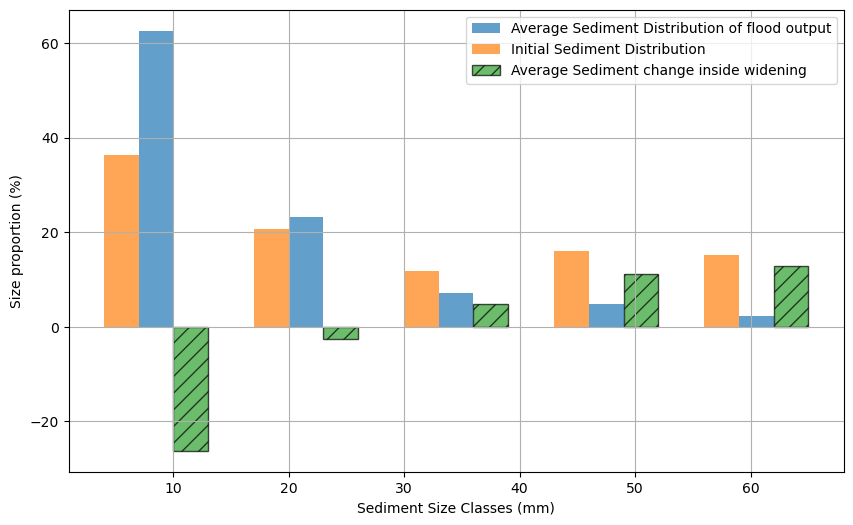

In [144]:
# plot histogram of average and initial sediment distributions
fig, ax = plt.subplots(figsize=(10,6))
width = 3
plt.grid()
ax.bar(np.array(Sizes_classes_mm)+width/2, average_sediment_percentage, width=width, label='Average Sediment Distribution of flood output', alpha=0.7)
ax.bar(np.array(Sizes_classes_mm)-width/2, sediment_init_percentage, width=width,label='Initial Sediment Distribution', alpha=0.7)

ax.bar(np.array(Sizes_classes_mm)+1.5*width, sediment_init_percentage-average_sediment_percentage, width=width, edgecolor='black', hatch="//", label='Average Sediment change inside widening ', alpha=0.7)

ax.set_xlabel('Sediment Size Classes (mm)')
ax.set_ylabel("Size proportion (%)")

plt.legend()

In [145]:
# transported sediment sizes during flood

X_out_time=X_out.copy()
#divide each row by the sum of the row to get percentages



X_out_time = X_out_time.div(X_out_time.sum(axis=1), axis=0)*100
print(X_out_time.head())
X_out_time.columns=['Size_7mm[%]', 'Size_20mm[%]', 'Size_33mm[%]', 'Size_46mm[%]', 'Size_59mm[%]']



X_out_time['Time[s]']=multi_scan['Time[s]']


   bnd_outflow[Qsed d=7 mm [m3/s]]   bnd_outflow[Qsed d=20 mm [m3/s]]   \
0                               NaN                                NaN   
1                               NaN                                NaN   
2                               NaN                                NaN   
3                               NaN                                NaN   
4                               NaN                                NaN   

   bnd_outflow[Qsed d=33 mm [m3/s]]   bnd_outflow[Qsed d=46 mm [m3/s]]   \
0                                NaN                                NaN   
1                                NaN                                NaN   
2                                NaN                                NaN   
3                                NaN                                NaN   
4                                NaN                                NaN   

   bnd_outflow[Qsed d=59 mm [m3/s]]   
0                                NaN  
1                         

(150000.0, 633150.0)

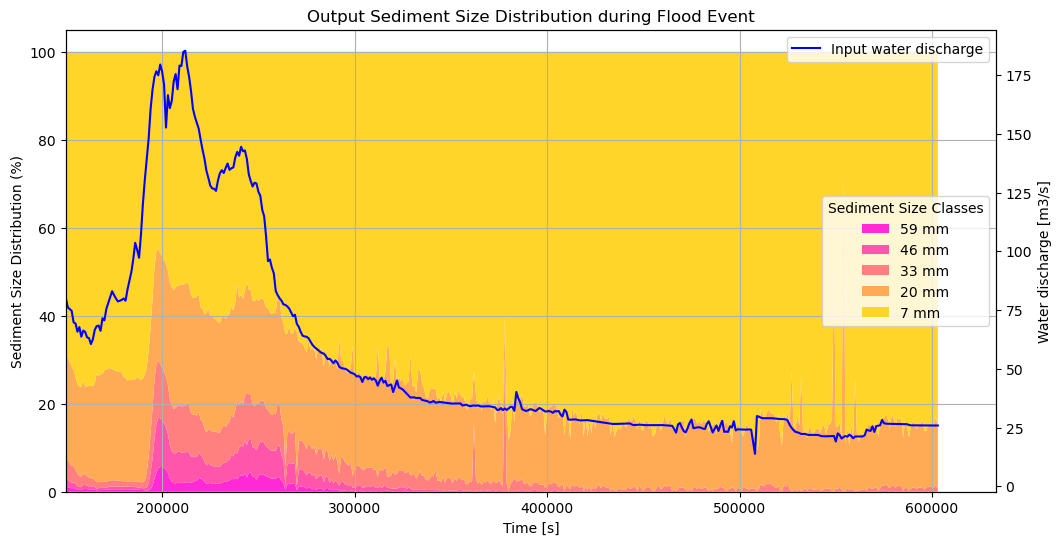

In [153]:
fig,ax=plt.subplots(figsize=(12,6))
ax.grid()
ax.stackplot(X_out_time['Time[s]'], 
              X_out_time['Size_59mm[%]'], 
              X_out_time['Size_46mm[%]'], 
              X_out_time['Size_33mm[%]'], 
              X_out_time['Size_20mm[%]'], 
              X_out_time['Size_7mm[%]'], 
              labels=['59 mm', '46 mm', '33 mm', '20 mm', '7 mm'],
              colors=sns.color_palette("spring", n_colors=5)
             )
ax.set_xlabel('Time [s]')
ax.set_ylabel('Sediment Size Distribution (%)')
ax.legend(title='Sediment Size Classes')
ax.set_title('Output Sediment Size Distribution during Flood Event')

#secondary axis
ax2=ax.twinx()
ax2.plot(multi_scan['Time[s]'], multi_scan['Q [m3/s]'], color='blue', label='Input water discharge')
ax2.set_ylabel('Water discharge [m3/s]')
ax2.legend(loc='upper right')

ax.set_xlim(150000)


# Transport analysis

In [147]:
# data
Dm=24e-3
rho=1000
rho_s=2650
mu=1e-3
g=9.81

d_star=Dm*(rho*g*(rho_s-rho)/mu**2)**(1/3)
d_star

607.1027856051232